# TGGCModern Synthetic Demo

This notebook builds a graph-coupled synthetic time series with shape `[T, N, 1]`, where each node has a single observed dimension. It trains `TGGCModern` on sliding windows, then aggregates overlapping forecasts back onto one long held-out validation series.

In [12]:
import math
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F

notebook_dir = os.getcwd()
repo_root = os.path.abspath(os.path.join(notebook_dir, ".."))
if repo_root not in sys.path:
    sys.path.append(repo_root)

from foreblocks.layers.graph import TGGCModern, TGGCModernConfig

torch.manual_seed(11)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device: {device}")

device: cuda


In [13]:
def make_ring_adjacency(num_nodes: int) -> torch.Tensor:
    adj = torch.zeros(num_nodes, num_nodes, dtype=torch.float32)
    for node_idx in range(num_nodes):
        adj[node_idx, node_idx] = 1.0
        adj[node_idx, (node_idx - 1) % num_nodes] = 1.0
        adj[node_idx, (node_idx + 1) % num_nodes] = 1.0
    return adj / adj.sum(dim=-1, keepdim=True)


def make_synthetic_tggc_series(
    length: int = 320,
    num_nodes: int = 8,
    noise: float = 0.035,
) -> tuple[torch.Tensor, torch.Tensor]:
    time = torch.arange(length, dtype=torch.float32)
    phase = 2.0 * math.pi * torch.arange(num_nodes, dtype=torch.float32) / float(num_nodes)
    adj = make_ring_adjacency(num_nodes)

    base_wave = torch.sin(2.0 * math.pi * time[:, None] / 24.0 + phase[None, :])
    fast_wave = 0.35 * torch.sin(2.0 * math.pi * time[:, None] / 8.0 - 0.5 * phase[None, :])
    slow_wave = 0.45 * torch.sin(2.0 * math.pi * time[:, None] / 48.0 + 0.25 * phase[None, :])
    trend = 0.3 * (time[:, None] / float(length)) * (1.0 + torch.arange(num_nodes, dtype=torch.float32)[None, :] / float(num_nodes))
    coupled = 0.65 * (base_wave + fast_wave) + 0.35 * torch.einsum("nm,tm->tn", adj, base_wave + fast_wave) + slow_wave + trend

    amp = 0.85 + 0.30 * torch.rand(1, num_nodes)
    drift = 0.04 * torch.randn(1, num_nodes) * (time[:, None] / float(length))
    target = coupled * amp + drift + noise * torch.randn(length, num_nodes)

    return target.unsqueeze(-1), adj


def make_window_batch(
    series: torch.Tensor,
    context_len: int,
    horizon: int,
    stride: int = 1,
) -> tuple[torch.Tensor, torch.Tensor]:
    total = series.size(0)
    max_start = total - context_len - horizon
    if max_start < 0:
        raise ValueError("Series is too short for the requested context and horizon.")

    xs = []
    ys = []
    for start in range(0, max_start + 1, stride):
        xs.append(series[start : start + context_len])
        ys.append(series[start + context_len : start + context_len + horizon])
    return torch.stack(xs, dim=0), torch.stack(ys, dim=0)


def aggregate_forecasts_to_full_series(
    predictions: torch.Tensor,
    full_series: torch.Tensor,
    seq_len: int,
    horizon: int,
    stride: int = 1,
    offset: int = 0,
    node_idx: int = 0,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, int]:
    pred_np = predictions.detach().cpu().numpy()
    series_np = full_series.detach().cpu().numpy()
    T = series_np.shape[0]
    N = pred_np.shape[0]
    starts = offset + seq_len + np.arange(N) * stride
    coverage_end = min(T, int(starts[-1] + horizon)) if N > 0 else 0

    acc = np.zeros(T, dtype=np.float64)
    cnt = np.zeros(T, dtype=np.float64)
    for k in range(N):
        s = int(starts[k])
        if s >= T:
            continue
        e = min(s + horizon, T)
        if e > s:
            acc[s:e] += pred_np[k, : e - s, node_idx, 0]
            cnt[s:e] += 1.0

    have = cnt > 0
    mean_pred = np.zeros(T, dtype=np.float64)
    mean_pred[have] = acc[have] / cnt[have]
    actual = series_np[:, node_idx, 0]
    return actual, mean_pred, have, starts, coverage_end


context_len = 96
horizon = 24
stride = 4

demo_series, true_adj = make_synthetic_tggc_series(length=220, num_nodes=8)
print(f"demo series shape: {tuple(demo_series.shape)}")

demo series shape: (220, 8, 1)


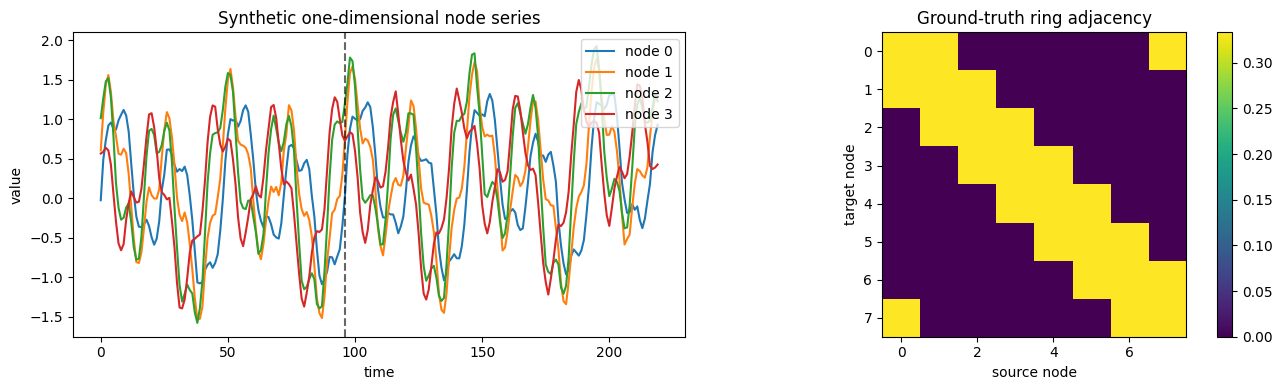

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for node_idx in range(4):
    axes[0].plot(demo_series[:, node_idx, 0].cpu(), label=f"node {node_idx}")
axes[0].axvline(context_len, color="black", linestyle="--", alpha=0.6)
axes[0].set_title("Synthetic one-dimensional node series")
axes[0].set_xlabel("time")
axes[0].set_ylabel("value")
axes[0].legend(loc="upper right")

im = axes[1].imshow(true_adj.cpu(), cmap="viridis")
axes[1].set_title("Ground-truth ring adjacency")
axes[1].set_xlabel("source node")
axes[1].set_ylabel("target node")
fig.colorbar(im, ax=axes[1], fraction=0.046)
plt.tight_layout()

In [15]:
cfg = TGGCModernConfig(
    num_nodes=demo_series.size(1),
    seq_len=context_len,
    horizon=horizon,
    in_channels=1,
    out_channels=1,
    hidden_channels=32,
    num_blocks=2,
    gegen_order=3,
    coarse_modes=16,
    fine_modes=16,
    use_fine_filter=True,
    decomp_kernel=17,
    graph_hidden_size=24,
    block_dropout=0.0,
)

warmup_x, warmup_y = make_window_batch(demo_series, context_len, horizon, stride=stride)
model = TGGCModern(cfg).to(device)
model.eval()

with torch.no_grad():
    pred0, learned_adj0 = model(warmup_x.to(device), static_adjacency=true_adj.to(device))
    pred0 = pred0.cpu()
    learned_adj0 = learned_adj0.cpu()

print(f"window batch shape:        {tuple(warmup_x.shape)}")
print(f"initial prediction shape:  {tuple(pred0.shape)}")
print(f"learned adjacency shape:   {tuple(learned_adj0.shape)}")
print(f"initial forecast mse:     {F.mse_loss(pred0, warmup_y).item():.4f}")

window batch shape:        (26, 96, 8, 1)
initial prediction shape:  (26, 24, 8, 1)
learned adjacency shape:   (8, 8)
initial forecast mse:     1.1853


In [16]:
train_series, train_adj = make_synthetic_tggc_series(length=420, num_nodes=8)
val_series, _ = make_synthetic_tggc_series(length=360, num_nodes=8)

train_x, train_y = make_window_batch(train_series, context_len, horizon, stride=2)
val_x, val_y = make_window_batch(val_series, context_len, horizon, stride=stride)

model = TGGCModern(cfg).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=3e-3)
losses = []
val_losses = []

train_x = train_x.to(device)
train_y = train_y.to(device)
val_x = val_x.to(device)
val_y = val_y.to(device)
train_adj = train_adj.to(device)

for step_idx in range(120):
    model.train()
    optimizer.zero_grad()
    pred, _ = model(train_x, static_adjacency=train_adj)
    loss = F.mse_loss(pred, train_y)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        val_pred, _ = model(val_x, static_adjacency=train_adj)
        val_loss = F.mse_loss(val_pred, val_y)
        val_losses.append(val_loss.item())

    if step_idx % 20 == 0 or step_idx == 119:
        print(f"step={step_idx:03d} train={loss.item():.4f} val={val_loss.item():.4f}")

step=000 train=2.1326 val=1.9570
step=020 train=0.1031 val=0.0899
step=040 train=0.0319 val=0.0295
step=060 train=0.0152 val=0.0170
step=080 train=0.0094 val=0.0136
step=100 train=0.0067 val=0.0118
step=119 train=0.0053 val=0.0109


validation windows: 61
coverage_end: 360
forecast-only mse: 0.0109
aggregated full-series mse over covered region: 0.0055
validation windows: 61
coverage_end: 360
forecast-only mse: 0.0109
aggregated full-series mse over covered region: 0.0059
validation windows: 61
coverage_end: 360
forecast-only mse: 0.0109
aggregated full-series mse over covered region: 0.0039
validation windows: 61
coverage_end: 360
forecast-only mse: 0.0109
aggregated full-series mse over covered region: 0.0065


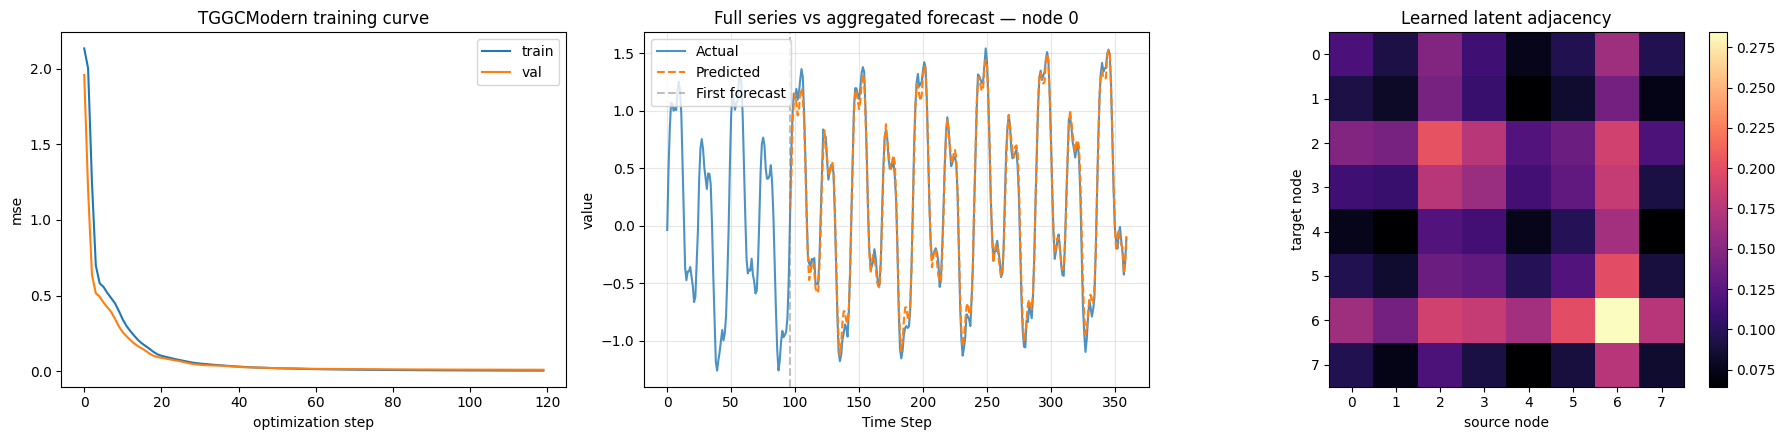

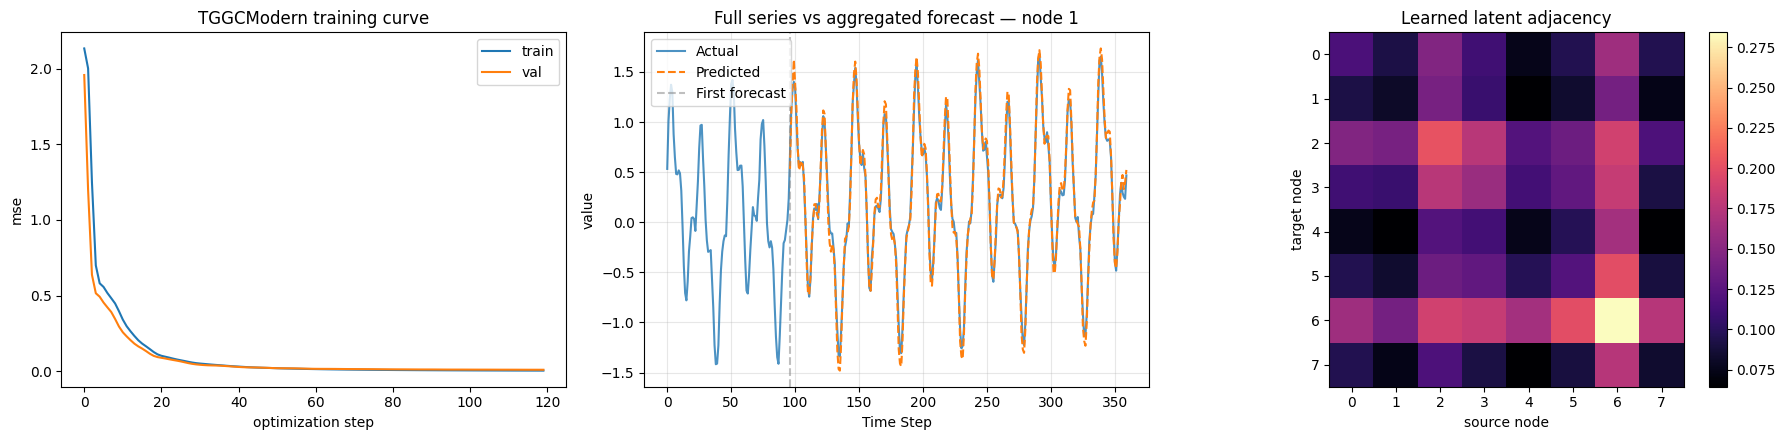

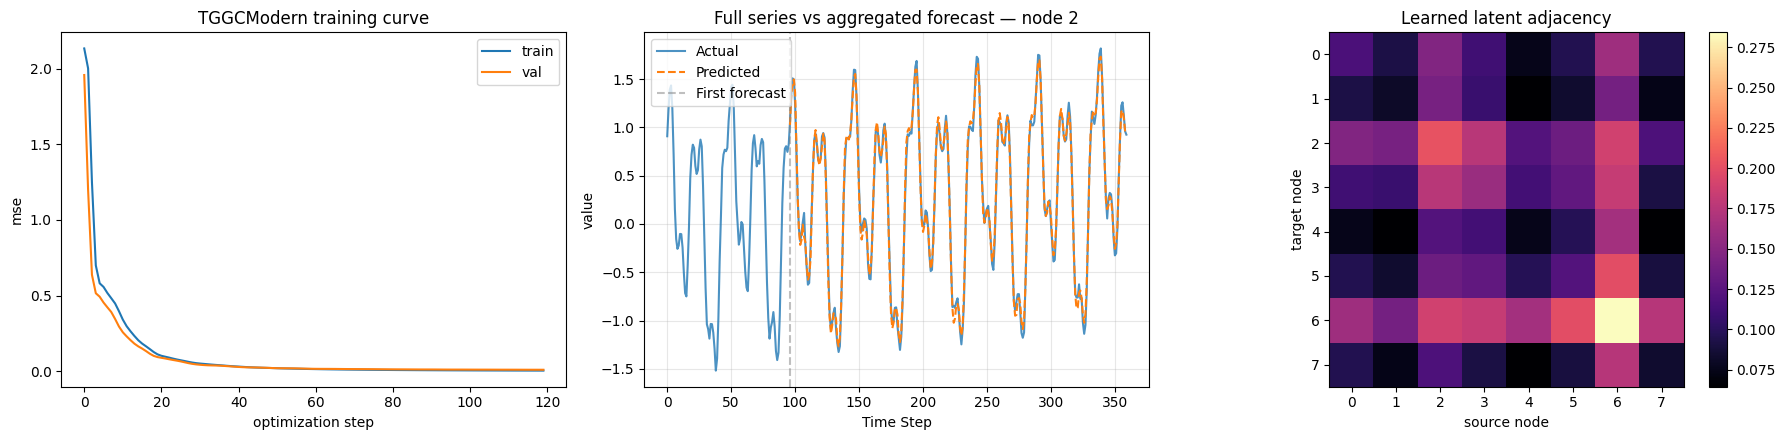

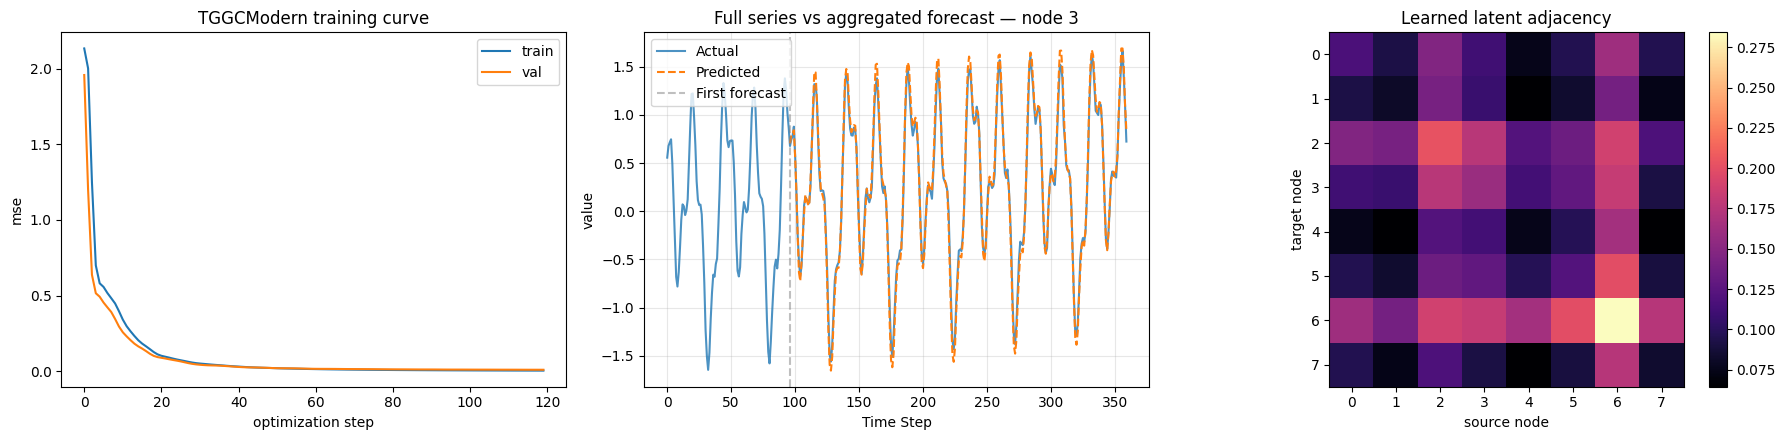

In [18]:
node_idx = 0

with torch.no_grad():
    eval_pred, eval_adj = model(val_x, static_adjacency=train_adj)

for node_idx in range(4):
    actual, mean_pred, have, starts, coverage_end = aggregate_forecasts_to_full_series(
        eval_pred.cpu(),
        val_series,
        seq_len=context_len,
        horizon=horizon,
        stride=stride,
        offset=0,
        node_idx=node_idx,
    )

    xs = np.arange(coverage_end)
    first_forecast_x = context_len

    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

    axes[0].plot(losses, label="train")
    axes[0].plot(val_losses, label="val")
    axes[0].set_title("TGGCModern training curve")
    axes[0].set_xlabel("optimization step")
    axes[0].set_ylabel("mse")
    axes[0].legend()

    axes[1].plot(xs, actual[:coverage_end], label="Actual", alpha=0.8, color="tab:blue")
    mask = have[:coverage_end]
    if mask.any():
        axes[1].plot(
            xs[mask],
            mean_pred[:coverage_end][mask],
            label="Predicted",
            linestyle="--",
            color="tab:orange",
        )
    axes[1].axvline(first_forecast_x, color="gray", linestyle="--", alpha=0.5, label="First forecast")
    axes[1].set_title(f"Full series vs aggregated forecast — node {node_idx}")
    axes[1].set_xlabel("Time Step")
    axes[1].set_ylabel("value")
    axes[1].legend(loc="upper left")
    axes[1].grid(True, alpha=0.3)

    im = axes[2].imshow(eval_adj.cpu(), cmap="magma")
    axes[2].set_title("Learned latent adjacency")
    axes[2].set_xlabel("source node")
    axes[2].set_ylabel("target node")
    fig.colorbar(im, ax=axes[2], fraction=0.046)

    plt.tight_layout()
    print(f"validation windows: {val_x.size(0)}")
    print(f"coverage_end: {coverage_end}")
    print(f"forecast-only mse: {F.mse_loss(eval_pred.cpu(), val_y.cpu()).item():.4f}")
    if mask.any():
        print(f"aggregated full-series mse over covered region: {np.mean((mean_pred[:coverage_end][mask] - actual[:coverage_end][mask]) ** 2):.4f}")